In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [15]:
dataset=pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [16]:
dataset.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [17]:
dataset.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [18]:
dataset.drop_duplicates(inplace=True)

In [19]:
dataset.shape

(7043, 21)

In [20]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [21]:
dataset['TotalCharges']=dataset['TotalCharges'].replace(' ' ,np.nan)

In [22]:
dataset['TotalCharges']=dataset['TotalCharges'].astype('float')

In [23]:
dataset['TotalCharges'].fillna(dataset['TotalCharges'].mean() , inplace=True)

In [24]:
dataset.value_counts(normalize=True)

customerID  gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  MultipleLines     InternetService  OnlineSecurity  OnlineBackup  DeviceProtection  TechSupport  StreamingTV  StreamingMovies  Contract        PaperlessBilling  PaymentMethod     MonthlyCharges  TotalCharges  Churn
0002-ORFBO  Female  0              Yes      Yes         9       Yes           No                DSL              No              Yes           No                Yes          Yes          No               One year        Yes               Mailed check      65.60           593.30        No       0.000142
0003-MKNFE  Male    0              No       No          9       Yes           Yes               DSL              No              No            No                No           No           Yes              Month-to-month  No                Mailed check      59.90           542.40        No       0.000142
0004-TLHLJ  Male    0              No       No          4       Yes           No                Fibe

In [25]:
dataset.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2265.000258
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,402.225000
50%,0.000000,29.000000,70.350000,1400.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [26]:
dataset.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Data Visualization

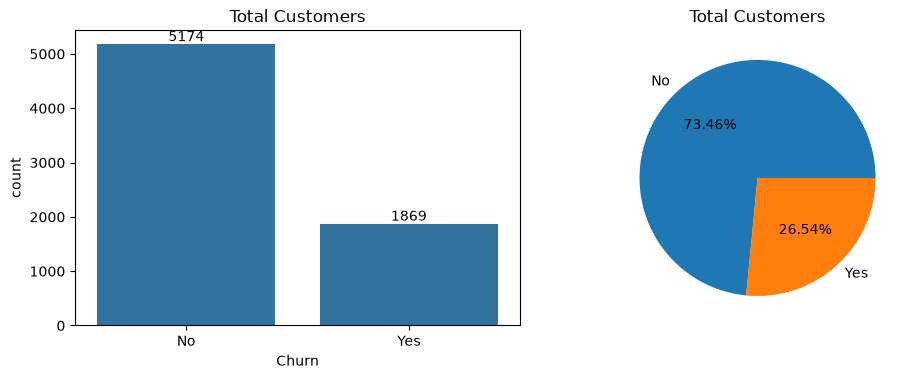

In [27]:
plt.figure(figsize=(10,7))
plt.subplot(2,2,1)
plt.title('Total Customers')
ax=sns.countplot(data=dataset ,x='Churn')
ax.bar_label(ax.containers[0])
plt.tight_layout()
plt.subplot(2,2,2)
gb=dataset.groupby('Churn').agg({'Churn':'count'})
plt.pie(gb['Churn'],labels=gb.index ,autopct='%1.2f%%')
plt.title('Total Customers')
plt.show()

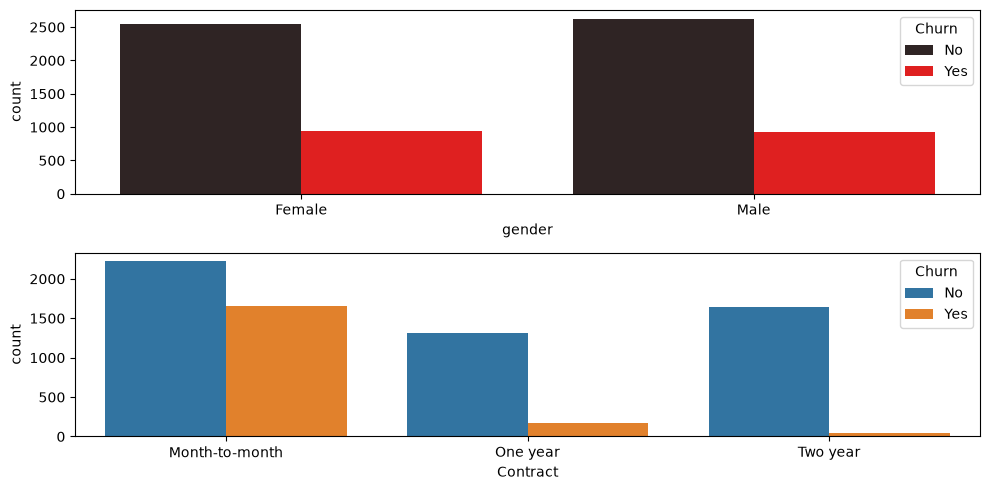

In [28]:
plt.figure(figsize=(10,5))
plt.subplot(2,1,1)
sns.countplot(data=dataset , x='gender' ,color='red' ,hue='Churn')
plt.tight_layout()
plt.subplot(2,1,2)
sns.countplot(data=dataset ,x='Contract' ,hue='Churn')
plt.tight_layout()

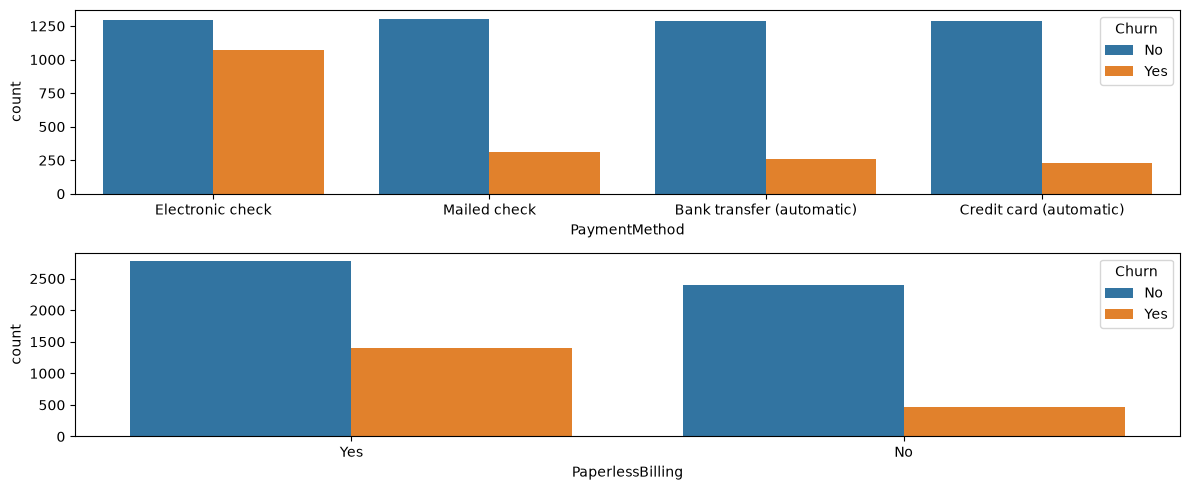

In [29]:
plt.figure(figsize=(12,5))
plt.subplot(2,1,1)
sns.countplot(data=dataset ,x='PaymentMethod',hue='Churn')
plt.tight_layout()
plt.subplot(2,1,2)
sns.countplot(data=dataset ,x='PaperlessBilling',hue='Churn')
plt.tight_layout()
plt.show()

Text(0, 0.5, 'Density')

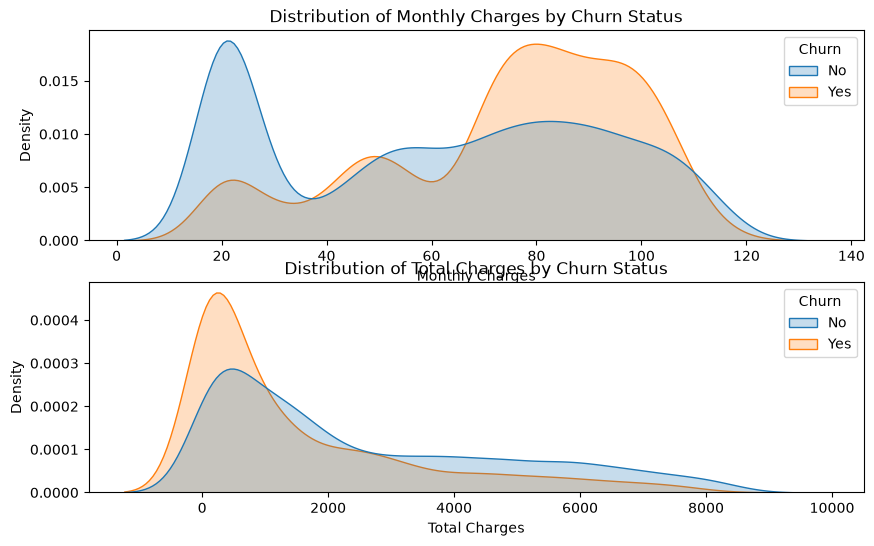

In [30]:
plt.figure(figsize=(10, 6))
plt.subplot(2,1,1)
sns.kdeplot(data=dataset, x='MonthlyCharges', hue='Churn', fill=True, common_norm=False)
plt.title('Distribution of Monthly Charges by Churn Status')
plt.xlabel('Monthly Charges')
plt.ylabel('Density')

plt.subplot(2,1,2)
sns.kdeplot(data=dataset, x='TotalCharges', hue='Churn', fill=True, common_norm=False)
plt.title('Distribution of Total Charges by Churn Status')
plt.xlabel('Total Charges')
plt.ylabel('Density')


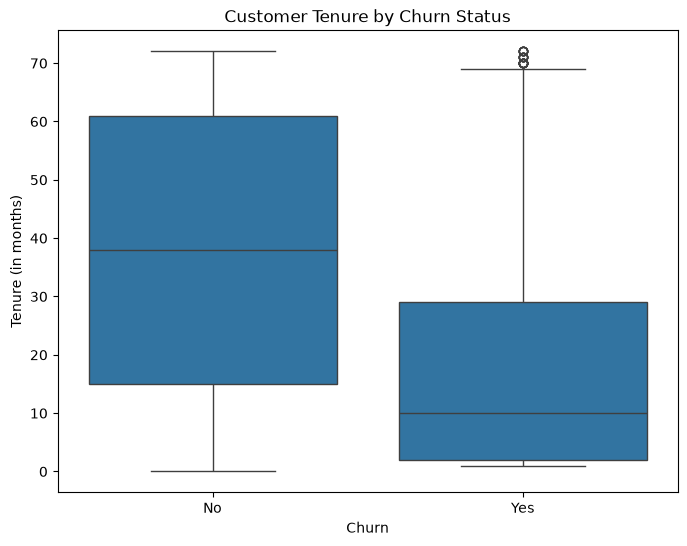

In [31]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Churn', y='tenure', data=dataset)
plt.title('Customer Tenure by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Tenure (in months)')
plt.show()

## Model Creation Buliding

In [32]:
from sklearn.model_selection import train_test_split , RandomizedSearchCV
from imblearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier ,AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder ,StandardScaler , OneHotEncoder
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
from sklearn.compose import ColumnTransformer

In [33]:
dataset.drop('customerID' , axis=1 , inplace=True)

In [34]:
input_data=dataset.drop('Churn',axis=1)
output=dataset['Churn']

In [35]:
Le=LabelEncoder()
output_en=Le.fit_transform(output)

In [37]:
X_train, X_test, y_train, y_test = train_test_split(input_data, output_en, test_size=0.2, random_state=42)

In [40]:
import sqlite3
import pandas as pd

numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
categorical_cols = [
    "gender", "SeniorCitizen", "Partner", "Dependents", "PhoneService",
    "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaperlessBilling", "PaymentMethod",
]

conn = sqlite3.connect("churn.db")
conn.execute("DELETE FROM training_reference_stats")

rows = []

for col in numeric_cols:
    rows.append((col, "mean", None, float(X_train[col].mean())))
    rows.append((col, "std", None, float(X_train[col].std())))

for col in categorical_cols:
    freqs = X_train[col].value_counts(normalize=True)
    for category, freq in freqs.items():
        rows.append((col, "category_freq", str(category), float(freq)))

conn.executemany(
    "INSERT INTO training_reference_stats (feature_name, stat_type, stat_key, stat_value) VALUES (?, ?, ?, ?)",
    rows,
)
conn.commit()
conn.close()

print(f"Stored {len(rows)} baseline stats.")

Stored 49 baseline stats.


In [41]:
categorical = []
for i in input_data.select_dtypes("object"):
    if not i in categorical:
        categorical.append(i)
        
numerical = []
for i in input_data.select_dtypes(["int" , "float"]):
    if not i in numerical:
        numerical.append(i)        

In [ ]:
X

In [24]:
encoder = ColumnTransformer(
    transformers=[
        ("st", StandardScaler(), numerical),
        ("ct", OneHotEncoder(handle_unknown="ignore"), categorical),
    ],
    remainder="passthrough"
)

## Created Pipeline

In [25]:
pipeline_Lr=Pipeline(steps=[
    ("preprocesser",encoder) ,
    ("sm" , SMOTE()),
    ('Lr',LogisticRegression(random_state=42,class_weight='balanced'))
]
)

In [26]:
pipeline_Dtr=Pipeline(steps=[
    ("preprocesser",encoder) ,
    ("sm" , SMOTE()),
    ('Dtr',DecisionTreeClassifier(random_state=42,class_weight='balanced'))
]
)

In [27]:
pipeline_Rdf=Pipeline(steps=[
    ("preprocesser",encoder) ,
    ("sm" , SMOTE()),
    ('Rdf',RandomForestClassifier(random_state=42,n_estimators=500,min_samples_split=5,min_samples_leaf=4,max_features='log2',max_depth=5,bootstrap=True))
]
)

In [28]:
pipeline_ada=Pipeline(steps=[
    ("preprocesser",encoder) ,
    ("sm" , SMOTE()),
    ('Ada',AdaBoostClassifier(random_state=42))
]
)

In [29]:
pipeline_knn=Pipeline(steps=[
   ("preprocesser",encoder) ,
    ("sm" , SMOTE()),
    ('knn',KNeighborsClassifier())
]
)

In [30]:
pipeline_svm=Pipeline(steps=[
    ("preprocesser",encoder) ,
    ("sm" , SMOTE()),
    ('svm',SVC(class_weight='balanced'))
]
)

In [31]:
pipeline_xgb = Pipeline(steps=[
    ("preprocessor", encoder),
    ("sm" , SMOTE()) ,
    ("xgb", XGBClassifier(eval_metric="logloss", random_state=42))
])

## Logostic Regression

In [32]:
pipeline_Lr.fit(X_train,y_train)

,steps,"[('preprocesser', ...), ('sm', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('st', ...), ('ct', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3


In [33]:
pipeline_Lr.fit(X_train, y_train)
print('Logistic Regression Classification Report:')
print(classification_report(y_test, pipeline_Lr.predict(X_test)))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.74      0.82      1036
           1       0.53      0.83      0.65       373

    accuracy                           0.76      1409
   macro avg       0.73      0.78      0.73      1409
weighted avg       0.82      0.76      0.77      1409



## Decision Tree

In [34]:
pipeline_Dtr.fit(X_train, y_train)
print('Decision Tree Classification Report:')
print(classification_report(y_test, pipeline_Dtr.predict(X_test)))

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.79      0.81      1036
           1       0.48      0.54      0.51       373

    accuracy                           0.72      1409
   macro avg       0.66      0.67      0.66      1409
weighted avg       0.74      0.72      0.73      1409



## Random Forest Classifier

In [35]:
pipeline_Rdf.fit(X_train, y_train)
print('Random Forest Classification Report:')
print(classification_report(y_test, pipeline_Rdf.predict(X_test)))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.75      0.82      1036
           1       0.53      0.78      0.64       373

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409



## ADA Boost Classifier

In [36]:
pipeline_ada.fit(X_train, y_train)
print('AdaBoost Classification Report:')
print(classification_report(y_test, pipeline_ada.predict(X_test)))

AdaBoost Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.75      0.82      1036
           1       0.53      0.80      0.64       373

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409



## KNN Classifier

In [37]:
pipeline_knn.fit(X_train, y_train)
print('KNeighbors Classification Report:')
print(classification_report(y_test, pipeline_knn.predict(X_test)))

KNeighbors Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.67      0.76      1036
           1       0.45      0.76      0.57       373

    accuracy                           0.69      1409
   macro avg       0.67      0.72      0.67      1409
weighted avg       0.77      0.69      0.71      1409



## SVM 

In [38]:
pipeline_svm.fit(X_train, y_train)
print('SVM Classification Report:')
print(classification_report(y_test, pipeline_svm.predict(X_test)))

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.79      0.84      1036
           1       0.57      0.76      0.65       373

    accuracy                           0.78      1409
   macro avg       0.73      0.77      0.75      1409
weighted avg       0.81      0.78      0.79      1409



## Xgb Classifier

In [39]:
pipeline_xgb.fit(X_train, y_train)
print('XGBoost Classification Report:')
print(classification_report(y_test, pipeline_xgb.predict(X_test)))

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.86      0.85      1036
           1       0.59      0.58      0.58       373

    accuracy                           0.78      1409
   macro avg       0.72      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409



## Checking Threshold

In [40]:
from imblearn.pipeline import Pipeline



param_dist = {
    "xgb__n_estimators": [100, 200, 300, 500, 700],
    "xgb__max_depth": [3, 4, 5, 6, 8, 10],
    "xgb__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "xgb__subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "xgb__colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "xgb__gamma": [0, 0.1, 0.3, 0.5, 1],
    "xgb__min_child_weight": [1, 3, 5, 7],
    "xgb__reg_alpha": [0, 0.01, 0.1, 1],
    "xgb__reg_lambda": [1, 1.5, 2, 3],
}

random_search = RandomizedSearchCV(
    estimator=pipeline_xgb,
    param_distributions=param_dist,
    n_iter=50,
    scoring="f1",
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'xgb__colsample_bytree': [0.6, 0.7, ...], 'xgb__gamma': [0, 0.1, ...], 'xgb__learning_rate': [0.01, 0.03, ...], 'xgb__max_depth': [3, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a fun

In [41]:
print('Classification Report' , classification_report(y_test ,random_search.predict(X_test)))

Classification Report               precision    recall  f1-score   support

           0       0.91      0.78      0.84      1036
           1       0.56      0.78      0.65       373

    accuracy                           0.78      1409
   macro avg       0.74      0.78      0.75      1409
weighted avg       0.82      0.78      0.79      1409



In [42]:
random_search.best_estimator_

,steps,"[('preprocessor', ...), ('sm', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('st', ...), ('ct', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3


In [43]:
from sklearn.metrics import precision_recall_curve, f1_score
import numpy as np

# Get predicted probabilities for class 1 (churn)
y_probs = random_search.best_estimator_.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)

# Find threshold that maximizes F1 for class 1
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Best threshold: {best_threshold:.3f}")
print(f"At this threshold -> Precision: {precisions[best_idx]:.3f}, Recall: {recalls[best_idx]:.3f}, F1: {f1_scores[best_idx]:.3f}")

# Apply it
y_pred_tuned = (y_probs >= best_threshold).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_tuned))

Best threshold: 0.568
At this threshold -> Precision: 0.614, Recall: 0.713, F1: 0.660
              precision    recall  f1-score   support

           0       0.89      0.84      0.86      1036
           1       0.61      0.71      0.66       373

    accuracy                           0.81      1409
   macro avg       0.75      0.78      0.76      1409
weighted avg       0.82      0.81      0.81      1409



In [44]:
from sklearn.metrics import precision_recall_curve, classification_report
import numpy as np

# Replace with your actual fitted RF pipeline/model variable
y_probs_rf = pipeline_Rdf.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs_rf)

f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Best threshold: {best_threshold:.3f}")
print(f"At this threshold -> Precision: {precisions[best_idx]:.3f}, Recall: {recalls[best_idx]:.3f}, F1: {f1_scores[best_idx]:.3f}")

y_pred_tuned_rf = (y_probs_rf >= best_threshold).astype(int)
print(classification_report(y_test, y_pred_tuned_rf))

Best threshold: 0.593
At this threshold -> Precision: 0.612, Recall: 0.686, F1: 0.647
              precision    recall  f1-score   support

           0       0.88      0.84      0.86      1036
           1       0.61      0.69      0.65       373

    accuracy                           0.80      1409
   macro avg       0.75      0.76      0.75      1409
weighted avg       0.81      0.80      0.81      1409



In [45]:
from sklearn.metrics import precision_recall_curve, classification_report
import numpy as np

# Replace with your actual fitted LR pipeline/model variable
y_probs_lr = pipeline_Lr.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs_lr)

f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Best threshold: {best_threshold:.3f}")
print(f"At this threshold -> Precision: {precisions[best_idx]:.3f}, Recall: {recalls[best_idx]:.3f}, F1: {f1_scores[best_idx]:.3f}")

y_pred_tuned_lr = (y_probs_lr >= best_threshold).astype(int)
print(classification_report(y_test, y_pred_tuned_lr))

Best threshold: 0.600
At this threshold -> Precision: 0.585, Recall: 0.753, F1: 0.659
              precision    recall  f1-score   support

           0       0.90      0.81      0.85      1036
           1       0.59      0.75      0.66       373

    accuracy                           0.79      1409
   macro avg       0.74      0.78      0.76      1409
weighted avg       0.82      0.79      0.80      1409



In [46]:
from sklearn.metrics import precision_recall_curve, classification_report
import numpy as np

# Replace with your actual fitted LR pipeline/model variable
y_probs_lr = pipeline_Dtr.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs_lr)

f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Best threshold: {best_threshold:.3f}")
print(f"At this threshold -> Precision: {precisions[best_idx]:.3f}, Recall: {recalls[best_idx]:.3f}, F1: {f1_scores[best_idx]:.3f}")

y_pred_tuned_lr = (y_probs_lr >= best_threshold).astype(int)
print(classification_report(y_test, y_pred_tuned_lr))

Best threshold: 0.500
At this threshold -> Precision: 0.482, Recall: 0.547, F1: 0.513
              precision    recall  f1-score   support

           0       0.83      0.79      0.81      1036
           1       0.48      0.55      0.51       373

    accuracy                           0.72      1409
   macro avg       0.66      0.67      0.66      1409
weighted avg       0.74      0.72      0.73      1409



In [48]:
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import RandomizedSearchCV

pipeline_rf = Pipeline(steps=[
    ("preprocessor", encoder),
    ("sm", SMOTE(random_state=42)),
    ("rf", RandomForestClassifier(random_state=42))
])

param_dist_rf = {
    "rf__n_estimators": [100, 200, 300, 500, 700],
    "rf__max_depth": [None, 5, 10, 15, 20, 30],
    "rf__min_samples_split": [2, 5, 10, 15],
    "rf__min_samples_leaf": [1, 2, 4, 6],
    "rf__max_features": ["sqrt", "log2", None],
    "rf__bootstrap": [True, False],
}

random_search_rf = RandomizedSearchCV(
    estimator=pipeline_rf,
    param_distributions=param_dist_rf,
    n_iter=50,
    scoring="f1",
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search_rf.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'rf__bootstrap': [True, False], 'rf__max_depth': [None, 5, ...], 'rf__max_features': ['sqrt', 'log2', ...], 'rf__min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a fun

In [49]:
import joblib

joblib.dump(random_search.best_estimator_, "xgb_best.pkl")
joblib.dump(random_search_rf.best_estimator_, "rf_best.pkl")

['rf_best.pkl']